# ALMA Interferometric ASDM guide

## Preparation

### Import Xarray

We will first use the standard API of Xarray Data Trees to open an example ASDM. Importing Xradio at this point is not needed, but it should be installed.

In [ ]:
import importlib
import os

try:
    # Ensure latest version of xradio is installed, with all dependencies and optional backends
    os.system("pip install --upgrade xradio[all]")
    print("Using xradio version", importlib.metadata.version("xradio"))
except ModuleNotFoundError as exc:  # # noqa: F821
    print(f"Could not find the package xradio: {exc}")

Xradio adds an `xradio_asdm` custom ackend to Xarray. We can see it in the list of backends available in Xarray together with for example `Zarr`. When Xradio is installed, the `xradio_asdm` can be given to the `engine` parameter of `xarray.open_datatree()` to open ASDMs.

In [2]:
import xarray as xr

xr.backends.list_engines()

{'scipy': <ScipyBackendEntrypoint>
   Open netCDF files (.nc, .cdf and .nc.gz) using scipy in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html,
 'store': <StoreBackendEntrypoint>
   Open AbstractDataStore instances in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html,
 'xradio_asdm': <ASDMBackendEntryPoint>
   Backend to open ASDM data as Xarray DataTrees, using the data schema of XRADIO ProcessingSet/MeasurementSet v4 
   Learn more at https://xradio.readthedocs.io/en/,
 'zarr': <ZarrBackendEntrypoint>
   Open zarr files (.zarr) using zarr in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ZarrBackendEntrypoint.html}

### Data Download

In [3]:
import toolviper

asdm_zip_name = "uid___A002_X10f6291_X12d9.zip"
try:
    toolviper.utils.data.download(file=asdm_zip_name)
except RuntimeError as exc:
    print(f"Could not download example ASDM via toolviper. Error: {exc}")
    print("Trying gdown...")
    try:
        import gdown
    except ImportError:
        import subprocess
        import sys

        subprocess.run([sys.executable, "-m", "pip", "install", "gdown"], check=True)
        import gdown

    import zipfile

    gdown.download(id="1sup-z1anlh_xYpTlhNalVhtOvbxzAg3S", output=asdm_zip_name)
    with zipfile.ZipFile(asdm_zip_name, "r") as zref:
        zref.extractall(None)

[2026-09-29 17:16:28,095]     INFO   toolviper:  Initializing download... 
[2026-09-29 17:16:28,181]    ERROR   toolviper:  [error]: Requested file not found in manifest: uid___A002_X10f6291_X12d9.zip
[2026-09-29 17:16:28,248]    ERROR   toolviper:  [error]: Use toolviper.utils.data.update() for the most recent version of the manifest.
[2026-09-29 17:16:28,249]     INFO   toolviper:  Use toolviper.utils.data.list_files() for available files. 
[2026-09-29 17:16:28,319]    ERROR   toolviper:  [error]: Missing files: ['uid___A002_X10f6291_X12d9.zip']
Could not download example ASDM via toolviper. Error: Files not found in the download manifest: ['uid___A002_X10f6291_X12d9.zip']
Trying gdown...


Downloading...
From (original): https://drive.google.com/uc?id=1sup-z1anlh_xYpTlhNalVhtOvbxzAg3S
From (redirected): https://drive.google.com/uc?id=1sup-z1anlh_xYpTlhNalVhtOvbxzAg3S&confirm=t&uuid=a2d93b96-750f-4cdb-a5a5-ccaab91b1a27
To: /home/fedemp/ws_xradio_asdm/xradio/docs/source/measurement_set/guides/uid___A002_X10f6291_X12d9.zip
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3.41M/3.41M [00:00<00:00, 6.23MB/s]


## Open an ASDM as a Processing Set

We can open the ASDM with `open_datatree()`. One relevant parameter is `include_processor_types` which selects the type of data (processor type) to include in the output DataTree. In this example we take only correlator data, not including the other types: `"RADIOMETER"` and `"SPECTROMETER"`.

In [4]:
asdm_ps_xdt = xr.open_datatree(
    "uid___A002_X10f6291_X12d9",
    engine="xradio_asdm",
    include_processor_types=["CORRELATOR"],
)

[2026-09-29 17:17:25,549]     INFO   toolviper:  Keeping only partitions for requested processor types. From the ConfigDescription table, with 4 rows, 2 rows are kept for processor types ['CORRELATOR'] 
[2026-09-29 17:17:25,550]     INFO   toolviper:  Keeping only partitions for requested spectral resolution types. From the ConfigDescription table, with 2 rows, 1 rows are kept for spectral resolution types ['FULL_RESOLUTION', 'BASEBAND_WIDE'] 
len(partition_groups)=8, while partitioning_df.shape[0]=136
[2026-09-29 17:17:25,612]     INFO   toolviper:   Time taken in create_partitions(): 0.130766 seconds 
[2026-09-29 17:17:25,613]     INFO   toolviper:  Opening partition for: execBlock [0], dataDescription: [5], scanIntent: ['CALIBRATE_FOCUS', 'CALIBRATE_WVR'], field: [0], scan: [3], subscan: [ 7  8  9  1 10  2 11  3 12  4 13  5 14  6], state: [0] 
[2026-09-29 17:17:25,723]     INFO   toolviper:  Opening partition for: execBlock [0], dataDescription: [5], scanIntent: ['CALIBRATE_POINTING

## Explore the Processing Set

The processing set opened from the ASDM can be explored via the standard Xarray DataTree interface and also via the `xr_ps` accessor:

In [5]:
asdm_ps_xdt.xr_ps.summary()

,name,scan_intents,shape,execution_block_UID,polarization,scan_name,spw_name,spw_intents,field_name,source_name,line_name,field_coords,session_reference_UID,scheduling_block_UID,project_UID,start_frequency,end_frequency
0,uid___A002_X10f6291_X12d9_0,"[['CALIBRATE_FOCUS', 'CALIBRATE_WVR']]","(28, 6, 128, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]",[3],X0000000000#ALMA_RB_03#BB_1#SW-01#FULL_RES_8,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,9.701319e+10,9.502881e+10
1,uid___A002_X10f6291_X12d9_1,"[['CALIBRATE_POINTING', 'CALIBRATE_WVR', 'CALI...","(40, 6, 128, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]","[1, 2]",X0000000000#ALMA_RB_03#BB_1#SW-01#FULL_RES_8,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,9.701319e+10,9.502881e+10
2,uid___A002_X10f6291_X12d9_2,"[['CALIBRATE_FOCUS', 'CALIBRATE_WVR']]","(28, 6, 128, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]",[3],X0000000000#ALMA_RB_03#BB_2#SW-01#FULL_RES_10,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,9.897119e+10,9.698681e+10
3,uid___A002_X10f6291_X12d9_3,"[['CALIBRATE_POINTING', 'CALIBRATE_WVR', 'CALI...","(40, 6, 128, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]","[1, 2]",X0000000000#ALMA_RB_03#BB_2#SW-01#FULL_RES_10,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,9.897119e+10,9.698681e+10
4,uid___A002_X10f6291_X12d9_4,"[['CALIBRATE_FOCUS', 'CALIBRATE_WVR']]","(28, 6, 128, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]",[3],X0000000000#ALMA_RB_03#BB_3#SW-01#FULL_RES_12,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,1.070288e+11,1.090132e+11
5,uid___A002_X10f6291_X12d9_5,"[['CALIBRATE_POINTING', 'CALIBRATE_WVR', 'CALI...","(40, 6, 128, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]","[1, 2]",X0000000000#ALMA_RB_03#BB_3#SW-01#FULL_RES_12,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,1.070288e+11,1.090132e+11
6,uid___A002_X10f6291_X12d9_6,"[['CALIBRATE_FOCUS', 'CALIBRATE_WVR']]","(28, 6, 128, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]",[3],X0000000000#ALMA_RB_03#BB_4#SW-01#FULL_RES_14,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,1.089868e+11,1.109712e+11
7,uid___A002_X10f6291_X12d9_7,"[['CALIBRATE_POINTING', 'CALIBRATE_WVR', 'CALI...","(40, 6, 128, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]","[1, 2]",X0000000000#ALMA_RB_03#BB_4#SW-01#FULL_RES_14,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,1.089868e+11,1.109712e+11


In [6]:
asdm_ps_xdt

<xarray.DataTree>
Group: /
│   Attributes:
│       type:     processing_set
├── Group: /uid___A002_X10f6291_X12d9_0
│   │   Dimensions:                     (time: 28, baseline_id: 6, frequency: 128,
│   │                                    polarization: 2, uvw_label: 3)
│   │   Coordinates:
│   │     * time                        (time) float64 224B 5.206e+09 ... 5.206e+09
│   │       scan_name                   (time) <U21 2kB '3' '3' '3' '3' ... '3' '3' '3'
│   │       field_name                  (time) <U10 1kB ...
│   │     * baseline_id                 (baseline_id) int64 48B 0 1 2 3 4 5
│   │       baseline_antenna1_name      (baseline_id) <U4 96B ...
│   │       baseline_antenna2_name      (baseline_id) <U4 96B ...
│   │     * frequency                   (frequency) float64 1kB 9.701e+10 ... 9.503e+10
│   │     * polarization                (polarization) <U2 16B 'XX' 'YY'
│   │     * uvw_label                   (uvw_label) <U1 12B 'u' 'v' 'w'
│   │   Data variables:
│   │       EFFECTIVE_INTEGRATION_TIME  (time, baseline_id) float64 1kB ...
│   │       TIME_CENTROID               (time, baseline_id) float64 1kB ...
│   │       VISIBILITY                  (time, baseline_id, frequency, polarization) complex128 688kB ...
│   │       WEIGHT                      (time, baseline_id, frequency, polarization) float64 344kB ...
│   │       FLAG                        (time, baseline_id, frequency, polarization) bool 43kB ...
│   │       UVW                         (time, baseline_id, uvw_label) float64 4kB ...
│   │   Attributes:
│   │       schema_version:    4.0.0
│   │       creator:           {'software_name': 'xradio', 'version': '1.2.3'}
│   │       creation_date:     2026-09-29T15:17:25.613615+00:00
│   │       type:              visibility
│   │       observation_info:  {'observer': ['nphillip'], 'release_date': '', 'projec...
│   │       processor_info:    {'type': 'CORRELATOR', 'sub_type': 'ALMA_CORRELATOR_MO...
│   │       data_groups:       {'base': {'correlated_data': 'VISIBILITY', 'flag': 'FL...
│   ├── Group: /uid___A002_X10f6291_X12d9_0/antenna_xds
│   │       Dimensions:                 (antenna_name: 3, cartesian_pos_label: 3,
│   │                                    receptor_label: 2)
│   │       Coordinates:
│   │         * antenna_name            (antenna_name) <U4 48B 'PM01' 'PM03' 'PM04'
│   │           station_name            (antenna_name) <U4 48B ...
│   │           mount                   (antenna_name) <U6 72B ...
│   │           telescope_name          (antenna_name) <U4 48B ...
│   │         * cartesian_pos_label     (cartesian_pos_label) <U1 12B 'x' 'y' 'z'
│   │         * receptor_label          (receptor_label) <U5 40B 'pol_0' 'pol_1'
│   │           polarization_type       (antenna_name, receptor_label) <U1 24B ...
│   │       Data variables:
│   │           ANTENNA_DISH_DIAMETER   (antenna_name) float64 24B ...
│   │           ANTENNA_POSITION        (antenna_name, cartesian_pos_label) float64 72B ...
│   │           ANTENNA_RECEPTOR_ANGLE  (antenna_name, receptor_label) float64 48B ...
│   │           ANTENNA_FOCUS_LENGTH    (antenna_name) float64 24B ...
│   │       Attributes:
│   │           type:                    antenna
│   │           relocatable_antennas:    True
│   │           overall_telescope_name:  ALMA
│   └── Group: /uid___A002_X10f6291_X12d9_0/field_and_source_base_xds
│           Dimensions:                       (field_name: 1, sky_dir_label: 2)
│           Coordinates:
│             * field_name                    (field_name) <U10 40B 'J2258-2758'
│               source_name                   (field_name) <U10 40B 'J2258-2758'
│             * sky_dir_label                 (sky_dir_label) <U3 24B 'ra' 'dec'
│           Data variables:
│               FIELD_PHASE_CENTER_DIRECTION  (field_name, sky_dir_label) float64 16B 6.0...
│               SOURCE_DIRECTION              (field_name, sky_dir_label) float64 16B ...
│           Attributes:
│               type:          fie

### Measurement Sets

The Processing Set Data Tree contains Data trees of MSv4s, including the correlated dataset and its sub-datasets:

In [8]:
msv4_xdt_0 = asdm_ps_xdt["uid___A002_X10f6291_X12d9_0"]
msv4_xdt_0.observation_info

{'observer': ['nphillip'],
 'release_date': '',
 'project_UID': 'uid://A002/X78fe3d/X1',
 'execution_block_UID': 'uid://A002/X10f6291/X12d9',
 'session_reference_UID': 'uid://A002/X10f6291/X1185',
 'observing_log': '[]',
 'scheduling_block_UID': 'uid://A002/X8a56fe/Xe3'}

#### Correlated dataset:

In [9]:
corr_xds = msv4_xdt_0.ds
corr_xds

<xarray.DatasetView> Size: 1MB
Dimensions:                     (time: 28, baseline_id: 6, frequency: 128,
                                 polarization: 2, uvw_label: 3)
Coordinates:
  * time                        (time) float64 224B 5.206e+09 ... 5.206e+09
    scan_name                   (time) <U21 2kB '3' '3' '3' '3' ... '3' '3' '3'
    field_name                  (time) <U10 1kB ...
  * baseline_id                 (baseline_id) int64 48B 0 1 2 3 4 5
    baseline_antenna1_name      (baseline_id) <U4 96B ...
    baseline_antenna2_name      (baseline_id) <U4 96B ...
  * frequency                   (frequency) float64 1kB 9.701e+10 ... 9.503e+10
  * polarization                (polarization) <U2 16B 'XX' 'YY'
  * uvw_label                   (uvw_label) <U1 12B 'u' 'v' 'w'
Data variables:
    EFFECTIVE_INTEGRATION_TIME  (time, baseline_id) float64 1kB ...
    TIME_CENTROID               (time, baseline_id) float64 1kB ...
    VISIBILITY                  (time, baseline_id, frequency, polarization) complex128 688kB ...
    WEIGHT                      (time, baseline_id, frequency, polarization) float64 344kB ...
    FLAG                        (time, baseline_id, frequency, polarization) bool 43kB ...
    UVW                         (time, baseline_id, uvw_label) float64 4kB ...
Attributes:
    schema_version:    4.0.0
    creator:           {'software_name': 'xradio', 'version': '1.2.3'}
    creation_date:     2026-09-29T15:17:25.613615+00:00
    type:              visibility
    observation_info:  {'observer': ['nphillip'], 'release_date': '', 'projec...
    processor_info:    {'type': 'CORRELATOR', 'sub_type': 'ALMA_CORRELATOR_MO...
    data_groups:       {'base': {'correlated_data': 'VISIBILITY', 'flag': 'FL...

#### Sub-datasets

In [10]:
antenna_xds = msv4_xdt_0["antenna_xds"]
antenna_xds

<xarray.DataTree 'antenna_xds'>
Group: /uid___A002_X10f6291_X12d9_0/antenna_xds
    Dimensions:                 (time: 28, baseline_id: 6, frequency: 128,
                                 polarization: 2, uvw_label: 3, antenna_name: 3,
                                 cartesian_pos_label: 3, receptor_label: 2)
    Coordinates:
      * antenna_name            (antenna_name) <U4 48B 'PM01' 'PM03' 'PM04'
        station_name            (antenna_name) <U4 48B ...
        mount                   (antenna_name) <U6 72B ...
        telescope_name          (antenna_name) <U4 48B ...
      * cartesian_pos_label     (cartesian_pos_label) <U1 12B 'x' 'y' 'z'
      * receptor_label          (receptor_label) <U5 40B 'pol_0' 'pol_1'
        polarization_type       (antenna_name, receptor_label) <U1 24B ...
    Inherited coordinates:
      * time                    (time) float64 224B 5.206e+09 ... 5.206e+09
      * baseline_id             (baseline_id) int64 48B 0 1 2 3 4 5
      * polarization            (polarization) <U2 16B 'XX' 'YY'
      * frequency               (frequency) float64 1kB 9.701e+10 ... 9.503e+10
      * uvw_label               (uvw_label) <U1 12B 'u' 'v' 'w'
    Data variables:
        ANTENNA_DISH_DIAMETER   (antenna_name) float64 24B ...
        ANTENNA_POSITION        (antenna_name, cartesian_pos_label) float64 72B ...
        ANTENNA_RECEPTOR_ANGLE  (antenna_name, receptor_label) float64 48B ...
        ANTENNA_FOCUS_LENGTH    (antenna_name) float64 24B ...
    Attributes:
        type:                    antenna
        relocatable_antennas:    True
        overall_telescope_name:  ALMA

In [11]:
field_and_source_xds = msv4_xdt_0.xr_ms.get_field_and_source_xds()
field_and_source_xds

<xarray.DatasetView> Size: 1kB
Dimensions:                       (field_name: 1, sky_dir_label: 2, time: 28,
                                   baseline_id: 6, polarization: 2,
                                   frequency: 128, uvw_label: 3)
Coordinates:
  * field_name                    (field_name) <U10 40B 'J2258-2758'
    source_name                   (field_name) <U10 40B 'J2258-2758'
  * sky_dir_label                 (sky_dir_label) <U3 24B 'ra' 'dec'
  * time                          (time) float64 224B 5.206e+09 ... 5.206e+09
  * baseline_id                   (baseline_id) int64 48B 0 1 2 3 4 5
  * polarization                  (polarization) <U2 16B 'XX' 'YY'
  * frequency                     (frequency) float64 1kB 9.701e+10 ... 9.503...
  * uvw_label                     (uvw_label) <U1 12B 'u' 'v' 'w'
Data variables:
    FIELD_PHASE_CENTER_DIRECTION  (field_name, sky_dir_label) float64 16B 6.0...
    SOURCE_DIRECTION              (field_name, sky_dir_label) float64 16B ...
Attributes:
    type:          field_and_source
    is_ephemeris:  False

In [12]:
field_and_source_xds.FIELD_PHASE_CENTER_DIRECTION

<xarray.DataArray 'FIELD_PHASE_CENTER_DIRECTION' (field_name: 1,
                                                  sky_dir_label: 2)> Size: 16B
array([[ 6.013093, -0.488213]])
Coordinates:
  * field_name     (field_name) <U10 40B 'J2258-2758'
    source_name    (field_name) <U10 40B 'J2258-2758'
  * sky_dir_label  (sky_dir_label) <U3 24B 'ra' 'dec'
Attributes:
    units:    rad
    frame:    fk5
    type:     sky_coord

[2026-09-29 17:17:27,099]     INFO   toolviper:  To include Continent outlines: `pip install cartopy` 


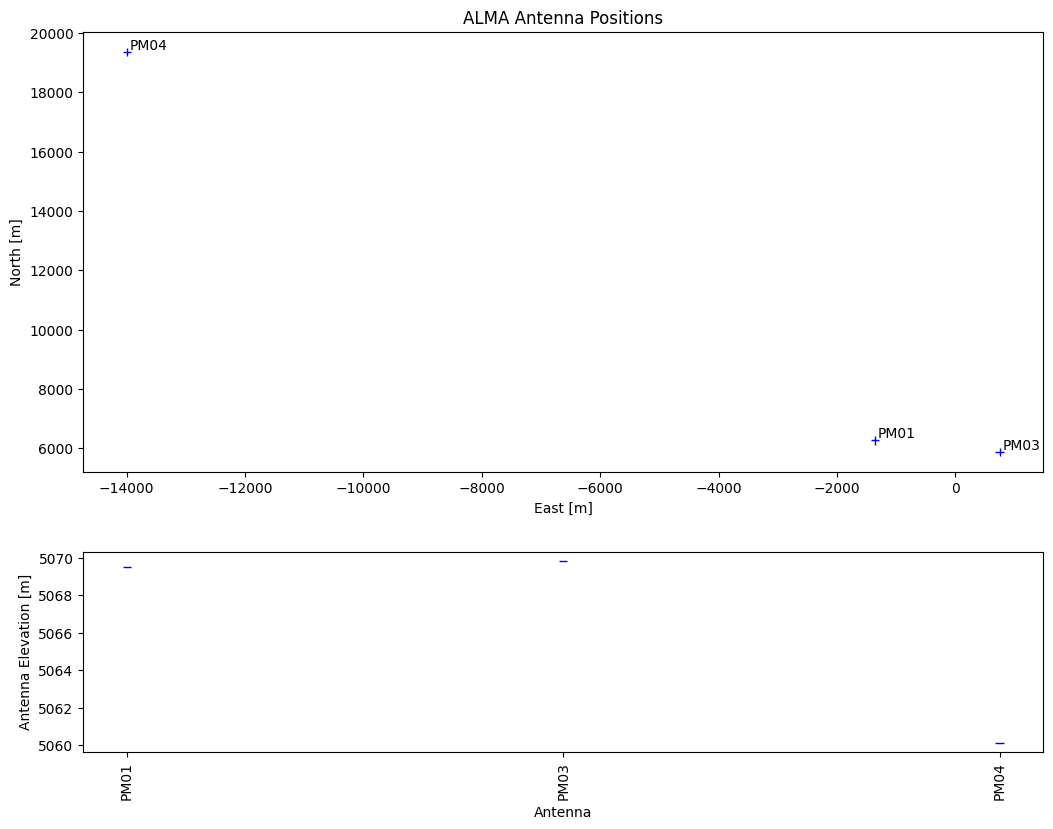

In [13]:
asdm_ps_xdt.xr_ps.plot_antenna_positions_2d()

## Opening ASDMs with filters by processor type and spectral resolution type.


In the following example we open a more complete Processing Set including the MSv4s that correspond to correlator type `RADIOMETER` (in addition to the `CORRELATOR` type used above). We also include all the spectral resolution types.

In [14]:
full_asdm_ps_xdt = xr.open_datatree(
    "uid___A002_X10f6291_X12d9",
    include_processor_types=["CORRELATOR", "RADIOMETER"],
    include_spectral_resolution_types=[
        "FULL_RESOLUTION",
        "CHANNEL_AVERAGE",
        "BASEBAND_WIDE",
    ],
    engine="xradio_asdm",
)

[2026-09-29 17:17:27,501]     INFO   toolviper:  Keeping only partitions for requested processor types. From the ConfigDescription table, with 4 rows, 4 rows are kept for processor types ['CORRELATOR', 'RADIOMETER'] 
[2026-09-29 17:17:27,503]     INFO   toolviper:  Keeping only partitions for requested spectral resolution types. From the ConfigDescription table, with 4 rows, 4 rows are kept for spectral resolution types ['FULL_RESOLUTION', 'CHANNEL_AVERAGE', 'BASEBAND_WIDE'] 
len(partition_groups)=26, while partitioning_df.shape[0]=442
[2026-09-29 17:17:27,647]     INFO   toolviper:   Time taken in create_partitions(): 0.263178 seconds 
[2026-09-29 17:17:27,648]     INFO   toolviper:  Opening partition for: execBlock [0], dataDescription: [0], scanIntent: ['CALIBRATE_FOCUS', 'CALIBRATE_WVR'], field: [0], scan: [3], subscan: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14], state: [0] 
[2026-09-29 17:17:28,655]     INFO   toolviper:  Opening partition for: execBlock [0], dataDescription: [0]

In [15]:
full_asdm_ps_xdt.xr_ps.summary()

,name,scan_intents,shape,execution_block_UID,polarization,scan_name,spw_name,spw_intents,field_name,source_name,line_name,field_coords,session_reference_UID,scheduling_block_UID,project_UID,start_frequency,end_frequency
0,uid___A002_X10f6291_X12d9_00,"[['CALIBRATE_FOCUS', 'CALIBRATE_WVR']]","(5040, 3, 1, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]",[3],X0000000000#ALMA_RB_03#BB_1#SQLD_0,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,9.602100e+10,9.602100e+10
1,uid___A002_X10f6291_X12d9_01,"[['CALIBRATE_POINTING', 'CALIBRATE_WVR', 'CALI...","(7200, 3, 1, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]","[1, 2]",X0000000000#ALMA_RB_03#BB_1#SQLD_0,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,9.602100e+10,9.602100e+10
2,uid___A002_X10f6291_X12d9_02,"[['CALIBRATE_FOCUS', 'CALIBRATE_WVR']]","(5040, 3, 1, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]",[3],X0000000000#ALMA_RB_03#BB_2#SQLD_1,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,9.797900e+10,9.797900e+10
3,uid___A002_X10f6291_X12d9_03,"[['CALIBRATE_POINTING', 'CALIBRATE_WVR', 'CALI...","(7200, 3, 1, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]","[1, 2]",X0000000000#ALMA_RB_03#BB_2#SQLD_1,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,9.797900e+10,9.797900e+10
4,uid___A002_X10f6291_X12d9_04,"[['CALIBRATE_FOCUS', 'CALIBRATE_WVR']]","(5040, 3, 1, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]",[3],X0000000000#ALMA_RB_03#BB_3#SQLD_2,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,1.080210e+11,1.080210e+11
5,uid___A002_X10f6291_X12d9_05,"[['CALIBRATE_POINTING', 'CALIBRATE_WVR', 'CALI...","(7200, 3, 1, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]","[1, 2]",X0000000000#ALMA_RB_03#BB_3#SQLD_2,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,1.080210e+11,1.080210e+11
6,uid___A002_X10f6291_X12d9_06,"[['CALIBRATE_FOCUS', 'CALIBRATE_WVR']]","(5040, 3, 1, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]",[3],X0000000000#ALMA_RB_03#BB_4#SQLD_3,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,1.099790e+11,1.099790e+11
7,uid___A002_X10f6291_X12d9_07,"[['CALIBRATE_POINTING', 'CALIBRATE_WVR', 'CALI...","(7200, 3, 1, 2)",uid://A002/X10f6291/X12d9,"[XX, YY]","[1, 2]",X0000000000#ALMA_RB_03#BB_4#SQLD_3,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,1.099790e+11,1.099790e+11
8,uid___A002_X10f6291_X12d9_08,"[['CALIBRATE_FOCUS', 'CALIBRATE_WVR']]","(14, 3, 4, 1)",uid://A002/X10f6291/X12d9,[XX],[3],WVR#NOMINAL_4,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,1.845500e+11,1.905500e+11
9,uid___A002_X10f6291_X12d9_09,"[['CALIBRATE_POINTING', 'CALIBRATE_WVR', 'CALI...","(20, 3, 4, 1)",uid://A002/X10f6291/X12d9,[XX],"[1, 2]",WVR#NOMINAL_4,[UNSPECIFIED],[J2258-2758],[J2258-2758],[],"[fk5, 22h58m05.96s, -27d58m21.26s]",uid://A002/X10f6291/X1185,uid://A002/X8a56fe/Xe3,uid://A002/X78fe3d/X1,1.845500e+11,1.905500e+11


## Other options

Other options supported include `with_pointing` and `pointing_for_only_spectral_resolution_types`. Support for pointing is currently under development.

The function that implements `open_datatree()` for ASDMs can be imported `from xradio.measurement_set._utils._asdm.open_asdm import open_asdm`. There is however no need to use this function directly and one can simply rely on Xarray's `open_datatree()`, as seen above.

## Saving the Processing Set to other formats

Once the ASDM is opened as a Processing Set, it can be saved to other formats supported in Xarray.

In [16]:
asdm_ps_xdt.to_zarr("asdm_uid___A002_X10f6291_X12d9_saved_as_zarr.zarr")

[2026-09-29 17:17:38,966]     INFO   toolviper:  Loaded FLAG array, with flag.shape=(28, 6, 128, 2) from len(bdf_paths)=14 blobs, time: 0.0159213 
[2026-09-29 17:17:39,862]     INFO   toolviper:  Loaded VISIBILITY array, with loaded_shape=(28, 6, 128, 2) from len(bdf_paths)=14 blobs, time: 0.065257 
[2026-09-29 17:17:39,979]     INFO   toolviper:  Loaded FLAG array, with flag.shape=(40, 6, 128, 2) from len(bdf_paths)=20 blobs, time: 0.0221687 
[2026-09-29 17:17:40,054]     INFO   toolviper:  Loaded VISIBILITY array, with loaded_shape=(40, 6, 128, 2) from len(bdf_paths)=20 blobs, time: 0.0370564 
[2026-09-29 17:17:40,151]     INFO   toolviper:  Loaded FLAG array, with flag.shape=(28, 6, 128, 2) from len(bdf_paths)=14 blobs, time: 0.0136601 
[2026-09-29 17:17:40,199]     INFO   toolviper:  Loaded VISIBILITY array, with loaded_shape=(28, 6, 128, 2) from len(bdf_paths)=14 blobs, time: 0.0195921 
[2026-09-29 17:17:40,330]     INFO   toolviper:  Loaded FLAG array, with flag.shape=(40, 6, 128